This program plots the radial profile of the Tycho SNR in 2003 vs 2021

In [13]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import numpy as np

In [14]:
Rprofile2003_file = 'BW2003_rprofile.fits'
Rprofile2021_file = 'BW2021_rprofile.fits'

In [27]:
with fits.open(Rprofile2003_file, ignore_missing_end=True) as hdu_list:
    hdu_list.verify('silentfix')
    hist_data2003 = hdu_list[1].data

with fits.open(Rprofile2021_file, ignore_missing_end=True) as hdu_list:
    hdu_list.verify('silentfix')
    hist_data2021 = hdu_list[1].data

# print(hist_data2003.columns)
# Grab radius data
radius2003 = hist_data2003['RMID']
radius2021 = hist_data2021['RMID']
# Need to convert from pixels to arcsec using plate scale of 0.492"
radius2003 = radius2003 * 0.492
radius2021 = radius2021 * 0.492

# Grab the flux values given in photons/cm**2/pixel**2/s
flux2003 = hist_data2003['SUR_FLUX']
flux2021 = hist_data2021['SUR_FLUX']
# Convert flux to arcsec
flux2003 = flux2003 * 4.1311388723641
flux2021 = flux2021 * 4.1311388723641

# Grab the flux error values given in pixels**-2
fluxerr2003 = hist_data2003['SUR_FLUX_ERR']
fluxerr2021 = hist_data2021['SUR_FLUX_ERR']
# Convert to arcsec**-2
fluxerr2003 = fluxerr2003 * 4.1311388723641
fluxerr2021 = fluxerr2021 * 4.1311388723641


In [28]:
# Optionally create an astropy Table to see the data
tab2003 = Table(
    [radius2003, flux2003, fluxerr2003],
    names=('Radius (arcsec)', 'Flux (photons/cm**2/arcsec**2/s)', 'Flux Error (photons/cm**2/arcsec**2/s)')
)
tab2021 = Table(
    [radius2021, flux2021, fluxerr2021],
    names=('Radius (arcsec)', 'Flux (photons/cm**2/arcsec**2/s)', 'Flux Error (photons/cm**2/arcsec**2/s)')
)
# print(tab2003)
print(tab2021)

 Radius (arcsec)   ... Flux Error (photons/cm**2/arcsec**2/s)
------------------ ... --------------------------------------
      2.1604071534 ...                 3.1228908795362136e-08
      6.2352215094 ...                 1.9739128558745396e-08
10.310035889999998 ...                 1.5861471219330728e-08
          14.38485 ...                 1.5379888217560082e-08
18.459664110000002 ...                 1.4834686917262283e-08
22.534478465999996 ...                 1.4106266391551787e-08
      26.609292822 ...                  1.221375888498885e-08
      30.684107178 ...                 1.0962633323963365e-08
34.758921533999995 ...                  1.016561957391203e-08
       38.83373589 ...                  9.444710393229235e-09
               ... ...                                    ...
246.64926287999998 ...                  3.916025319961143e-09
250.72407821999997 ...                  3.683495400824567e-09
254.79889355999998 ...                  3.322676167102645e-09
      25

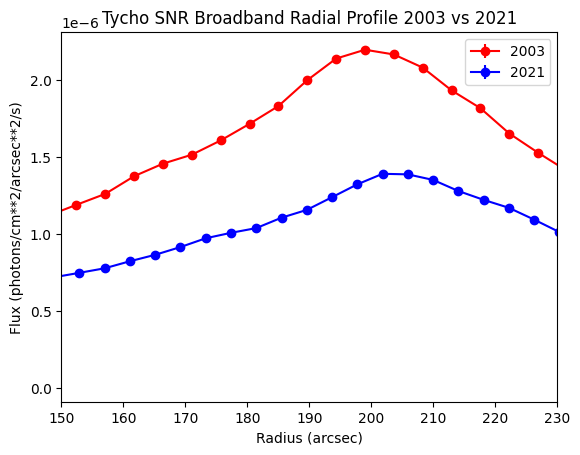

In [47]:
plt.errorbar(radius2003, flux2003, yerr=fluxerr2003, fmt='ro-',label='2003')
plt.errorbar(radius2021, flux2021, yerr=fluxerr2021, fmt='bo-', label='2021')
plt.xlim(150, 230)
plt.xlabel('Radius (arcsec)')
plt.ylabel('Flux (photons/cm**2/arcsec**2/s)')
plt.title("Tycho SNR Broadband Radial Profile 2003 vs 2021")
plt.legend()
plt.show()